# Bài 1: Xây dựng mạng LSTM gồm 5 lớp với hidden size là 256 cho bài toán phân loại văn bản. Huấn luyện mô hình này trên bộ dữ liệu UIT-VSFC (Vietnamese Student Feedback Corpus) sử dụng Adam làm phương thức tối ưu tham số và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

## Sau đây là code minh họa cho bài toán phân loại topic với 4 nhãn

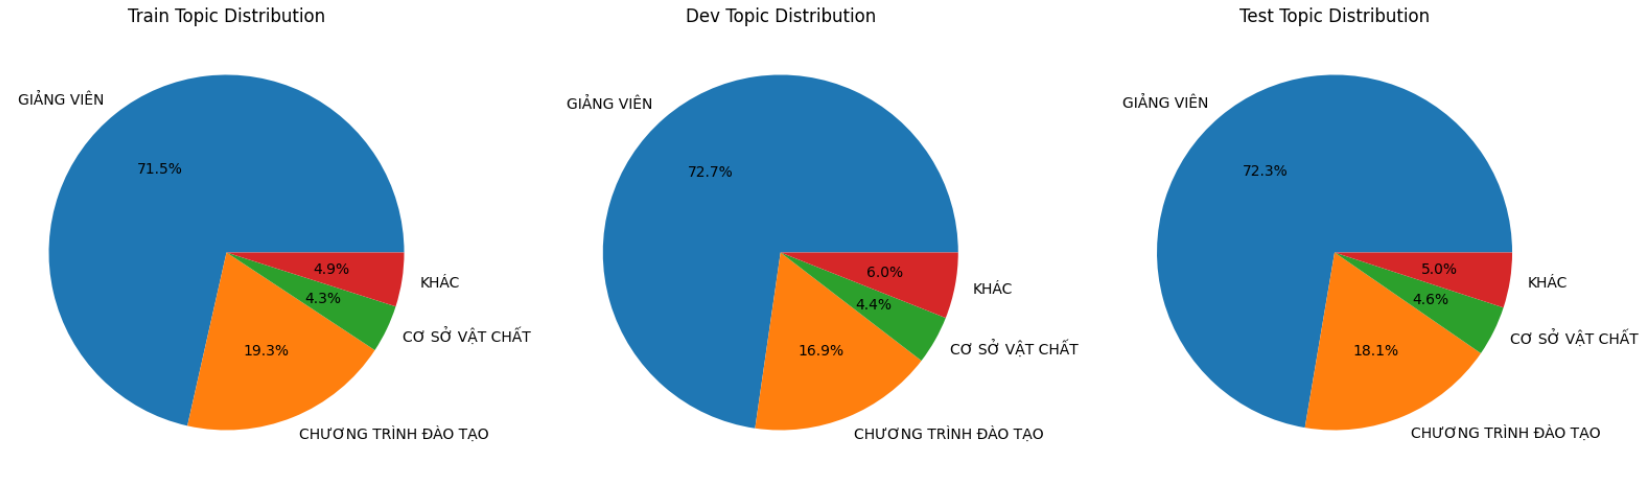

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import một số thư viện cần thiết

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf

# 2. Tải dữ liệu đã tiền xử lý

In [6]:
def load_dataset(base_path):
    """
    Hàm đọc dữ liệu từ đường dẫn thư mục chứa các file csv đã tiền xử lý.
    """
    try:
        # Định nghĩa đường dẫn file
        train_path = os.path.join(base_path, 'train_processed.csv')
        dev_path = os.path.join(base_path, 'dev_processed.csv')
        test_path = os.path.join(base_path, 'test_processed.csv')

        # Đọc dữ liệu
        df_train = pd.read_csv(train_path)
        df_dev = pd.read_csv(dev_path)
        df_test = pd.read_csv(test_path)

        # Chuyển đổi dữ liệu input sang chuỗi ký tự (đề phòng giá trị null)
        df_train['segmented_sentence'] = df_train['segmented_sentence'].astype(str)
        df_dev['segmented_sentence'] = df_dev['segmented_sentence'].astype(str)
        df_test['segmented_sentence'] = df_test['segmented_sentence'].astype(str)

        print(f"Kích thước tập Train: {df_train.shape}")
        print(f"Kích thước tập Dev: {df_dev.shape}")
        print(f"Kích thước tập Test: {df_test.shape}")

        return df_train, df_dev, df_test

    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra đường dẫn. {e}")
        return None, None, None

# Đường dẫn đến thư mục dữ liệu
DATA_DIR = '/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/preprocessed_UIT-VN_Student_FB'

df_train, df_dev, df_test = load_dataset(DATA_DIR)

Kích thước tập Train: (11426, 6)
Kích thước tập Dev: (1583, 6)
Kích thước tập Test: (3166, 6)


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sentence            11426 non-null  object
 1   sentiment           11426 non-null  int64 
 2   topic               11426 non-null  int64 
 3   num_words           11426 non-null  int64 
 4   clean_sentence      11426 non-null  object
 5   segmented_sentence  11426 non-null  object
dtypes: int64(3), object(3)
memory usage: 535.7+ KB


In [8]:
df_train.head()

,sentence,sentiment,topic,num_words,clean_sentence,segmented_sentence
0,slide giáo trình đầy đủ,2,1,6,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,nhiệt tình giảng dạy gần gũi với sinh viên,2,0,11,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần,0,1,9,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full điểm chuyên_cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,18,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ thông_tin và các thiết_...
4,thầy giảng bài hay có nhiều bài tập ví dụ nga...,2,0,15,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


# 3. Mã hóa dữ liệu (Tokenization & Encoding)

## a. Chọn các siêu tham số - Dựa trên phân tích EDA

In [9]:
MAX_LEN = 120           # Độ dài cố định cho mỗi câu (bao phủ đa số dữ liệu)
NUM_CLASSES = 4

## b. Xây dựng các hàm xử lý thủ công - Tạo tập từ điển + encoding

In [10]:
def create_vocab(texts):
    """Tạo bộ từ điển từ danh sách văn bản"""
    vocab_set = set()
    for text in texts:
        # Tách từ theo khoảng trắng (vì đã segmented từ file EDA)
        words = str(text).split()
        vocab_set.update(words)
    return sorted(list(vocab_set))

def create_word_index(vocab_list):
    """Tạo mapping từ chữ sang số"""
    # 0 dành cho Padding, 1 dành cho từ lạ (Unknown)
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word in vocab_list:
        word2idx[word] = idx
        idx += 1
    return word2idx

In [11]:
def encode_and_pad(texts, word2idx, max_len):
    """Chuyển câu văn thành dãy số và padding"""
    data = []
    for text in texts:
        words = str(text).split()
        seq = []
        for w in words:
            # Nếu từ có trong từ điển thì lấy ID, không thì lấy ID của <UNK>
            if w in word2idx:
                seq.append(word2idx[w])
            else:
                seq.append(word2idx['<UNK>'])

        # Thủ tục Padding (Thêm số 0 vào sau)
        if len(seq) < max_len:
            # Nếu ngắn hơn max_len -> thêm 0 vào cuối
            seq = seq + [0] * (max_len - len(seq))
        else:
            # Nếu dài hơn -> cắt bớt
            seq = seq[:max_len]

        data.append(seq)
    return np.array(data)

## THỰC THI

In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Tạo từ điển chỉ trên tập TRAIN (để tránh data leakage)
vocab_list = create_vocab(df_train['segmented_sentence'])
word2idx = create_word_index(vocab_list)
VOCAB_SIZE = len(word2idx) + 1 # +1 để an toàn cho index cuối cùng

print(f"Kích thước từ điển (Vocab size): {VOCAB_SIZE}")

# Mã hóa dữ liệu đầu vào (Input)
print("Đang mã hóa dữ liệu...")
X_train = encode_and_pad(df_train['segmented_sentence'], word2idx, MAX_LEN)
X_dev = encode_and_pad(df_dev['segmented_sentence'], word2idx, MAX_LEN)
X_test = encode_and_pad(df_test['segmented_sentence'], word2idx, MAX_LEN)

# Mã hóa nhãn (Label) sang one-hot
y_train = to_categorical(df_train['topic'], NUM_CLASSES)
y_dev = to_categorical(df_dev['topic'], NUM_CLASSES)
y_test = to_categorical(df_test['topic'], NUM_CLASSES)

# Kiểm tra kết quả
print("\n--- KÍCH THƯỚC DỮ LIỆU SAU KHI XỬ LÝ ---")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_dev:   {X_dev.shape}   | y_dev:   {y_dev.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nVí dụ mẫu đầu tiên (X_train[0]):\n{X_train[0]}")

Kích thước từ điển (Vocab size): 3391
Đang mã hóa dữ liệu...

--- KÍCH THƯỚC DỮ LIỆU SAU KHI XỬ LÝ ---
X_train: (11426, 120) | y_train: (11426, 4)
X_dev:   (1583, 120)   | y_dev:   (1583, 4)
X_test:  (3166, 120)  | y_test:  (3166, 4)

Ví dụ mẫu đầu tiên (X_train[0]):
[2159  788 3258    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


Lưu ý, ở đây ta đã thực tiện tách từ, nên số từ có thể nhiều hơn so với thống kê EDA khi chưa tách từ. Câu đầu tiên trong tập train là `slide giáo_trình đầy_đủ` nên khi emcoding ta chỉ có 3 token đại diện cho 3 từ.

# 4. Xây dựng mô hình LSTM

In [13]:
#  Cấu hình tham số
VOCAB_SIZE = len(word2idx) + 1 # +1 để an toàn cho index cuối cùng
MAX_LEN = 120 # Như đã trình bày ở trên
NUM_CLASSES = 4
EMBEDDING_DIM = 256

## a. Mô hình theo yêu cầu đề

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

def build_5_layers_lstm(
        vocab_size,
        input_length,
        num_classes,
        EMBEDDING_DIM=256,
        HIDDEN_SIZE=256, # Yêu cầu đề bài
        DROPOUT_RATE=0.4
    ):

    model = tf.keras.Sequential([
        Input(shape=(input_length,)),
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),

        # LSTM layer 1
        LSTM(HIDDEN_SIZE, return_sequences=True, name="LSTM_1"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # LSTM layer 2
        LSTM(HIDDEN_SIZE, return_sequences=True, name="LSTM_2"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # LSTM layer 3
        LSTM(HIDDEN_SIZE, return_sequences=True, name="LSTM_3"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # LSTM layer 4
        LSTM(HIDDEN_SIZE, return_sequences=True, name="LSTM_4"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # LSTM layer 5 – final
        LSTM(HIDDEN_SIZE, return_sequences=False, name="LSTM_5"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        Dense(num_classes, activation='softmax', name="Output")
    ], name="Deep_LSTM_256_5Layers")

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    return model

In [16]:
# Khởi tạo mô hình
print(f"Xây dựng mô hình 5 layers với Vocab Size: {VOCAB_SIZE}")
_5_layer_model = build_5_layers_lstm(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)
_5_layer_model.summary()

Xây dựng mô hình 5 layers với Vocab Size: 3391


Model: "Deep_LSTM_256_5Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 120, 256)       │       868,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_3 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_4 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_5 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,500,804 (13.35 MB)

 Trainable params: 3,498,244 (13.34 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # <--- Import thêm cái này

# 1. Định nghĩa Checkpoint
checkpoint = ModelCheckpoint(
    filepath='best_lstm_model.keras',  # Tên file để lưu model (đuôi .keras hoặc .h5)
    monitor='val_loss',                # Theo dõi chỉ số loss trên tập validation
    save_best_only=True,               # True: Chỉ lưu đè lên file nếu model hiện tại tốt hơn model trước đó
    mode='min',                        # 'min' vì chúng ta muốn loss càng nhỏ càng tốt (nếu monitor='val_accuracy' thì mode='max')
    verbose=1                          # In ra thông báo khi có model mới được lưu
)

# (Tùy chọn) 2. Thêm EarlyStopping để dừng sớm nếu model không tốt lên nữa
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,                        # Chờ 5 epochs, nếu không cải thiện thì dừng
    restore_best_weights=True          # Tự động khôi phục trọng số tốt nhất về biến model khi dừng
)

In [23]:
# 3. Truyền vào hàm fit
history_5_layers = _5_layer_model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint, early_stopping] # <--- Thêm danh sách callbacks vào đây
)

Epoch 1/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9102 - loss: 0.2796
Epoch 1: val_loss improved from inf to 0.66143, saving model to best_lstm_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9102 - loss: 0.2796 - val_accuracy: 0.7865 - val_loss: 0.6614
Epoch 2/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9068 - loss: 0.2821
Epoch 2: val_loss did not improve from 0.66143
358/358 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.9068 - loss: 0.2821 - val_accuracy: 0.7587 - val_loss: 0.7659
Epoch 3/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9083 - loss: 0.2836
Epoch 3: val_loss did not improve from 0.66143
358/358 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9083 - loss: 0.2835 - val_accuracy: 0.7442 - val_loss: 0.8458
Epoch 4/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9170 - loss: 0.2621
Epoch 4: val_loss improved from 0.66143 to 0.58109, saving model to best_lstm_model.keras
358/358 ━━━━━━━━━━━━━━━━━

In [24]:
from tensorflow.keras.models import load_model
from sklearn.metrics import f1_score, classification_report

print("Đang load lại model tốt nhất từ file...")
best_model = load_model('best_lstm_model.keras')

print("\nĐang dự đoán trên tập Test...")
y_pred_probs = best_model.predict(X_test, verbose=0) # Dùng best_model
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Tính F1-Macro
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')

print(f"\n>> F1-MACRO (Best 5 layers Model): {macro_f1:.4f}")
print("\nChi tiết báo cáo:")
target_names = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác']
print(classification_report(y_true_class, y_pred_class, target_names=target_names))

Đang load lại model tốt nhất từ file...

Đang dự đoán trên tập Test...

>> F1-MACRO (Best 5 layers Model): 0.6848

Chi tiết báo cáo:
                precision    recall  f1-score   support

    Giảng viên       0.92      0.90      0.91      2290
  Chương trình       0.66      0.63      0.64       572
Cơ sở vật chất       0.73      0.86      0.79       145
          Khác       0.35      0.45      0.39       159

      accuracy                           0.83      3166
     macro avg       0.67      0.71      0.68      3166
  weighted avg       0.84      0.83      0.83      3166



--- BIỂU ĐỒ HUẤN LUYỆN (CÓ ĐÁNH DẤU BEST MODEL) ---


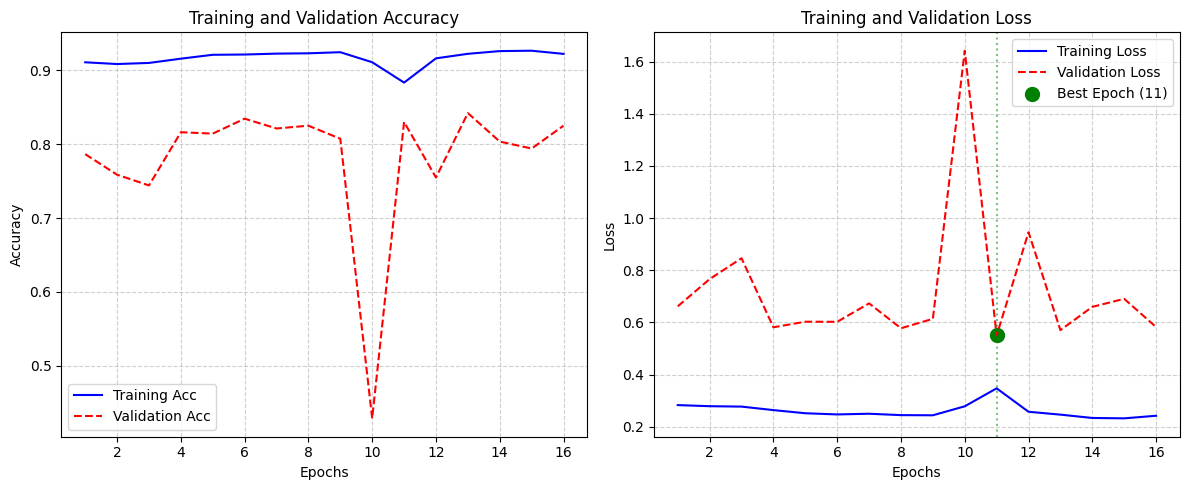

In [25]:
def plot_training_history_improved(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # --- TÌM EPOCH TỐT NHẤT (Dựa trên Val Loss thấp nhất) ---
    best_epoch_idx = np.argmin(val_loss) # Trả về index (bắt đầu từ 0)
    best_epoch_val = best_epoch_idx + 1   # Epoch thực tế (bắt đầu từ 1)
    best_loss = val_loss[best_epoch_idx]

    plt.figure(figsize=(12, 5))

    # 1. Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Acc')
    plt.plot(epochs, val_acc, 'r--', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ nhìn

    # 2. Biểu đồ Loss (Quan trọng nhất)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')

    # --- ĐÁNH DẤU ĐIỂM TỐT NHẤT ---
    # Vẽ một điểm màu xanh lá tại epoch có val_loss thấp nhất
    plt.scatter(best_epoch_val, best_loss, s=100, c='green', label=f'Best Epoch ({best_epoch_val})')
    # Vẽ đường gióng xuống
    plt.axvline(x=best_epoch_val, color='green', linestyle=':', alpha=0.5)

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- THỰC THI ---
print("--- BIỂU ĐỒ HUẤN LUYỆN (CÓ ĐÁNH DẤU BEST MODEL) ---")
plot_training_history_improved(history_5_layers)

**1. Hiện tượng Overfitting (Quá khớp) diễn ra nghiêm trọng:**
Biểu đồ thể hiện rõ sự phân kỳ lớn (generalization gap) giữa tập Train và Validation:

* **Training:** Accuracy tăng rất đều và đạt mức cao (>92%), Loss giảm đều xuống mức thấp (0.25). Điều này chứng tỏ mô hình có khả năng học rất tốt.
* **Validation:** Accuracy dao động cực kỳ mạnh, Loss không có xu hướng giảm đều mà lại rất hỗn loạn.

**2. Nguyên nhân tiềm năng:**
* **Độ phức tạp của mô hình quá lớn:** Với 3 triệu tham số (5 lớp LSTM, Hidden size 256) nhưng chỉ huấn luyện trên `11.000 mẫu dữ liệu`. Mạng lưới quá sâu đã học cả những nhiễu (noise) của tập train thay vì học các đặc trưng tổng quát.

* **Các kỹ thuật Regularization** Dù đã áp dụng `BatchNormalization` và `Dropout` (0.4), nhưng do lượng dữ liệu quá ít so với số lượng tham số, các kỹ thuật này không hiệu quả lắm khi ngăn cản mô hình overfit.

* **Vấn đề dữ liệu (Imbalanced Data):** Sự biến thiên mạnh của đường `val_loss` (đường đỏ giật lên xuống liên tục) củng cố giả thuyết về **mất cân bằng mẫu**. Khi batch rơi vào các mẫu thuộc lớp thiểu số (như lớp `Khác`), gradient bị thay đổi đột ngột khiến Loss nhảy vọt (như tại Epoch 10).


## b. Mô hình đơn giản để tránh overfiting

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Cấu hình
EMBEDDING_DIM = 128
# Giảm xuống 128 vì Bi-LSTM sẽ nhân đôi vector này lên thành 256
HIDDEN_SIZE = 128

def build_bi_lstm(vocab_size, input_length, num_classes):
    model = tf.keras.Sequential([
        Input(shape=(input_length,)),
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),

        # --- Layer 1: Bi-LSTM (Đọc 2 chiều) ---
        # Output thực tế sẽ là 128 * 2 = 256 chiều
        Bidirectional(LSTM(HIDDEN_SIZE, return_sequences=True, name="LSTM_Fwd")),
        BatchNormalization(),
        Dropout(0.4),

        # --- Layer 2: Bi-LSTM (Final) ---
        # Đây là lớp chốt hạ, gom thông tin 2 chiều lại
        Bidirectional(LSTM(HIDDEN_SIZE, return_sequences=False, name="LSTM_Bwd")),
        BatchNormalization(),
        Dropout(0.4),

        # Output Layer
        Dense(num_classes, activation='softmax', name="Output")
    ], name="Bi_LSTM_2Layers_Balanced")

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0001), # Giữ LR nhỏ để hội tụ mượt
        metrics=['accuracy']
    )
    return model

# --- 1. KHỞI TẠO ---
print(f"Xây dựng mô hình Bi-LSTM (2 Layers, 128x2 units)...")
bi_model = build_bi_lstm(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)
bi_model.summary()

# --- 2. CHECKPOINT ---
checkpoint_bi = ModelCheckpoint(
    filepath='best_bi_lstm.keras',  # Tên file mới
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping_bi = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# --- 3. TRAIN ---
history_bi = bi_model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint_bi, early_stopping_bi],
    verbose=1
)

Xây dựng mô hình Bi-LSTM (2 Layers, 128x2 units)...


Model: "Bi_LSTM_2Layers_Balanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 120, 128)       │       434,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 120, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094,532 (4.18 MB)

 Trainable params: 1,093,508 (4.17 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4135 - loss: 1.5793
Epoch 1: val_loss improved from inf to 1.20290, saving model to best_bi_lstm.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.4141 - loss: 1.5776 - val_accuracy: 0.6804 - val_loss: 1.2029
Epoch 2/30
356/358 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7469 - loss: 0.7585
Epoch 2: val_loss improved from 1.20290 to 0.59004, saving model to best_bi_lstm.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7473 - loss: 0.7578 - val_accuracy: 0.8130 - val_loss: 0.5900
Epoch 3/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8410 - loss: 0.5300
Epoch 3: val_loss improved from 0.59004 to 0.44697, saving model to best_bi_lstm.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8410 - loss: 0.5299 - val_accuracy: 0.8654 - val_loss: 0.4470
Epoch 4/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8594 - loss: 0.4446
Epoch 4: val_loss did not improve from

In [51]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, f1_score, confusion_matrix

model_path = 'best_bi_lstm.keras'
best_simple_model = load_model(model_path)

print("Đang dự đoán trên tập Test...")
y_pred_probs = best_simple_model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Tính F1-Macro
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
print(f"F1-MACRO: {macro_f1:.4f}")

# Classification Report
target_names = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác']
print("CHI TIẾT BÁO CÁO:")
print(classification_report(y_true_class, y_pred_class, target_names=target_names))


Đang dự đoán trên tập Test...
F1-MACRO: 0.7501
CHI TIẾT BÁO CÁO:
                precision    recall  f1-score   support

    Giảng viên       0.93      0.92      0.93      2290
  Chương trình       0.70      0.76      0.73       572
Cơ sở vật chất       0.94      0.82      0.88       145
          Khác       0.48      0.45      0.47       159

      accuracy                           0.86      3166
     macro avg       0.76      0.74      0.75      3166
  weighted avg       0.87      0.86      0.86      3166



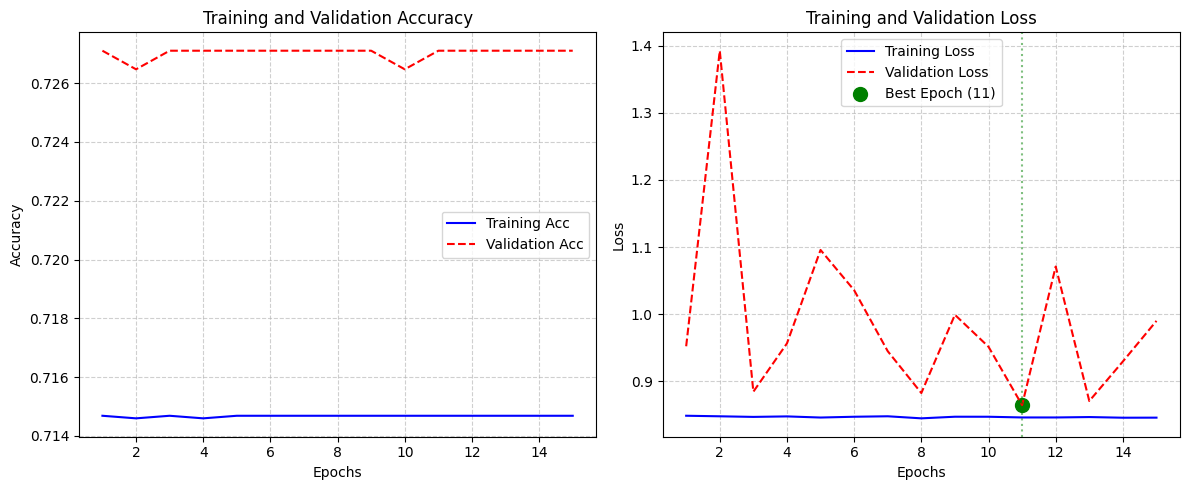

In [53]:
plot_training_history_improved(history_simple)

- Kết quả: Mô hình Bi-LSTM (2 lớp) đạt hiệu suất cao (F1 = 0.75), vượt trội so với LSTM 5 layers trước đó (0.68) nhờ khả năng nắm bắt ngữ cảnh hai chiều.

- Vấn đề: Hiện tượng Overfitting vẫn xuất hiện sau Epoch 6 (Val Loss tăng ngược trở lại), cho thấy mô hình 1 triệu tham số vẫn hơi "dư thừa" so với tập dữ liệu mỏng (11.000 mẫu).

Kết luận: Kiến trúc mô hình đã tối ưu. Để vượt ngưỡng F1 0.8, mấu chốt nằm ở việc mở rộng dữ liệu (Data Augmentation) hoặc chuyển sang Pre-trained Model.